# STUDENT PERFORMANCE EXPLORATORY DATA ANALYSIS, YO

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student_performance_dataset.csv')

print(df.head())
print(df.describe())
print(df.info())
print(df.isna().sum())

   student_id  gender  study_time_hours  attendance_percent  sleep_hours  \
0           1    Male               4.0                98.0          6.5   
1           2  Female               6.3               100.0          5.7   
2           3    Male               4.9                85.3          7.9   
3           4    Male               2.6                77.5          8.0   
4           5    Male               2.2                89.6          4.6   

  parental_education internet_access extracurricular_activities part_time_job  \
0          Bachelors             Yes                        Yes            No   
1        High School             Yes                        Yes           Yes   
2          Bachelors             Yes                         No           Yes   
3                NaN             Yes                        Yes            No   
4          Bachelors             Yes                         No           Yes   

   previous_grade  final_exam_score final_grade  
0     

## Printing out interesting bar plots, because improvements look suspicious !

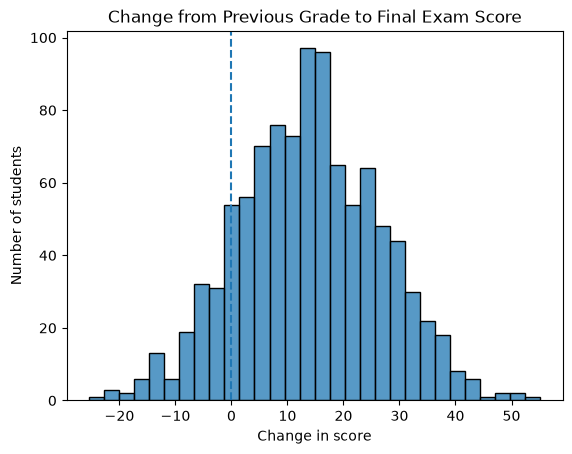

In [19]:
df['grade_change'] = df['final_exam_score'] - df['previous_grade']

sns.histplot(df["grade_change"], bins=30)

plt.axvline(0, linestyle="--")
plt.xlabel("Change in score")
plt.ylabel("Number of students")
plt.title("Change from Previous Grade to Final Exam Score")

plt.show()

## Check correlations

In [20]:
df[['previous_grade', 'final_exam_score', 'grade_change']].corr()

,previous_grade,final_exam_score,grade_change
previous_grade,1.000000,0.406327,-0.664903
final_exam_score,0.406327,1.000000,0.412323
grade_change,-0.664903,0.412323,1.000000


## Did student's grades improved or declined? 

In [21]:
df['grade_improved'] = df['grade_change'] > 0
print(df['grade_improved'].value_counts())

grade_improved
True     866
False    134
Name: count, dtype: int64


## Is there any difference between students who improved and declined?

In [29]:
# params: student_id  gender  study_time_hours  attendance_percent  sleep_hours 
# parental_education internet_access extracurricular_activities part_time_job
# previous_grade  final_exam_score final_grade
numeric_comparison = df.groupby("grade_improved")[
    ["study_time_hours", "attendance_percent", "sleep_hours"]
].mean()

numeric_comparison

,study_time_hours,attendance_percent,sleep_hours
grade_improved,,,
False,2.419403,80.464925,6.613433
True,3.748845,85.808314,6.828291


In [ ]:
categorical_columns = [
    "gender",
    "parental_education",
    "internet_access",
    "extracurricular_activities",
    "part_time_job"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(s
        pd.crosstab(
            df["grade_improved"],
            df[column],
            normalize="index"
        ).round(3)
    )


--- gender ---
gender          Female   Male
grade_improved               
False            0.515  0.485
True             0.509  0.491

--- parental_education ---
parental_education  Bachelors  High School  Masters    PhD
grade_improved                                            
False                   0.359        0.436    0.162  0.043
True                    0.341        0.391    0.211  0.058

--- internet_access ---
internet_access     No    Yes
grade_improved               
False            0.261  0.739
True             0.128  0.872

--- extracurricular_activities ---
extracurricular_activities     No    Yes
grade_improved                          
False                       0.455  0.545
True                        0.424  0.576

--- part_time_job ---
part_time_job      No    Yes
grade_improved              
False           0.560  0.440
True            0.703  0.297
